In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from eht_inspection.alist import *


/Users/ningyuanxu/mamba/envs/eht-py/bin/python


/Users/ningyuanxu/Projects/eht/eat/eat/hops/util.py:25: UserWarning: cannot import mk4 (did you run hops.bash?), mk4 file access will not work
  warnings.warn("cannot import mk4 (did you run hops.bash?), mk4 file access will not work")


In [2]:
avg_scan_M87_stage3 = load_alist(multi_stage=True)
avg_2s_M87_stage3 = load_alist(avg_time=2, multi_stage=True)

avg_scan_M87_stage5 = load_alist(stage=5, multi_stage=True)
avg_2s_M87_stage5 = load_alist(stage=5, avg_time=2, multi_stage=True)

### 1. SNR vs. time across stages

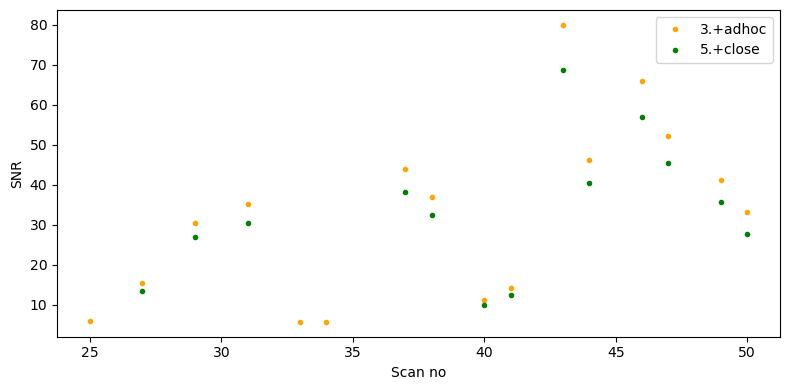

In [ ]:
baseline_pol_filter = {
    "baseline": ("==", "LN"),
    "polarization": ("==", "LL"),
}

fig = plot_snr_across_stages(
    {
        "3.+adhoc": avg_scan_M87_stage3,
        "5.+close": avg_scan_M87_stage5,
    },
    filters=baseline_pol_filter,
    colors=["orange", "green"],
)

### 2. Plot coherence histograms and find outliers

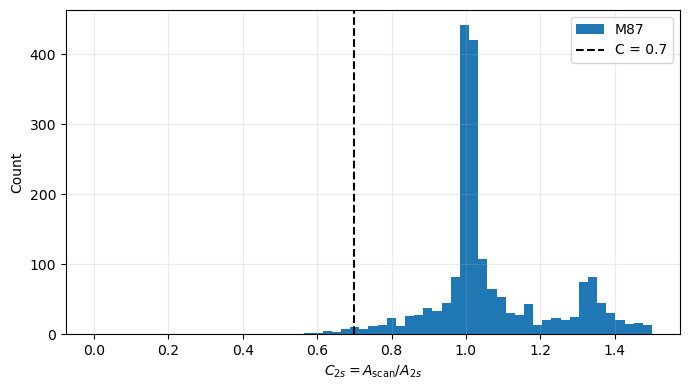

In [4]:
fig, C_2s = plot_coherence_hist(
    avg_scan_M87_stage3,
    avg_2s_M87_stage3,
    threshold=0.7,
    label="M87",
)

plt.show()

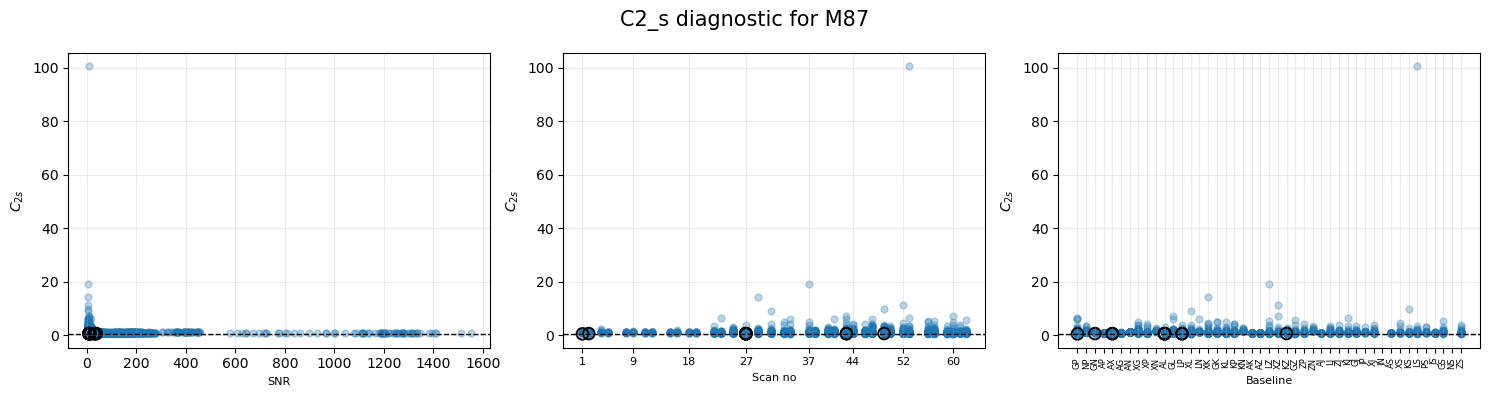

In [5]:
fig, outliers_m87 = plot_coherence_diagnostics(
    avg_scan_M87_stage3,
    C=C_2s,
    threshold=0.7,
    snr_min=7,
    source_label="M87",
)

plt.show()

### 3. Time series of multiplr quantities for specified stations and polarizations / polarization difference

For stations other than ALMA, when using only circular polarizations, the plot will exclude baseline connecting to ALMA

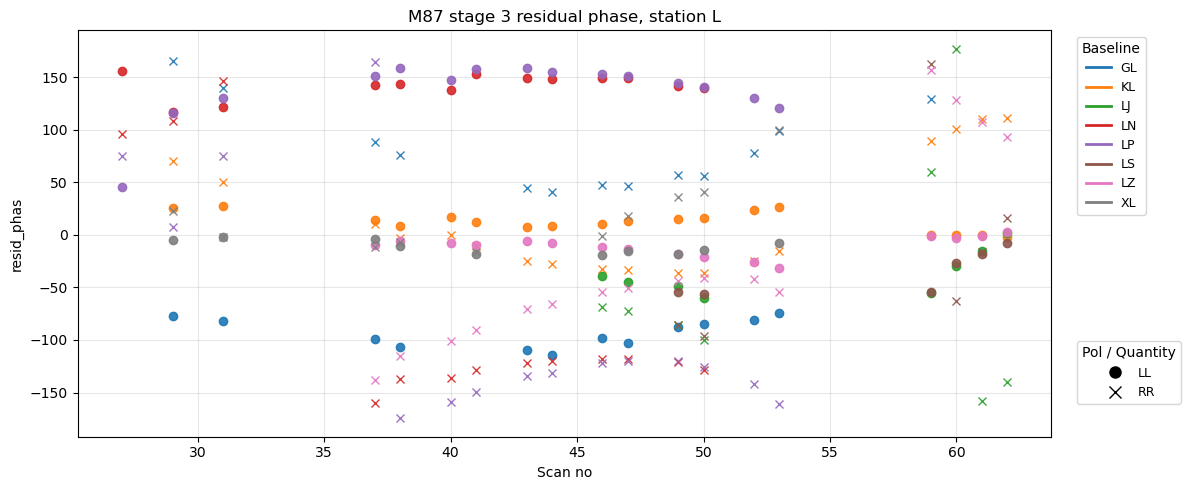

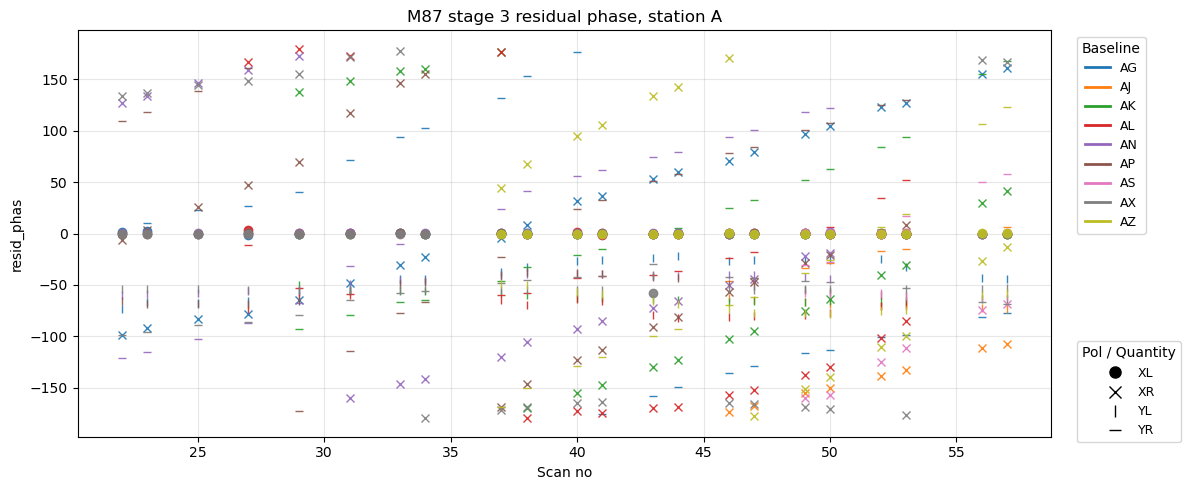

In [6]:
figs = plot_quantity_vs_scan_by_station( # type: ignore
    avg_scan_M87_stage3, # pyright: ignore[reportUndefinedVariable]
    stations=["L", "A"],
    quantities="resid_phas",
    pols={
        "default": ["RR", "LL"],
        "A": ["XR", "XL", "YR", "YL"],
    },
    filters={
        "snr": (">=", 7),
    },
    title_prefix="M87 stage 3 residual phase"
)

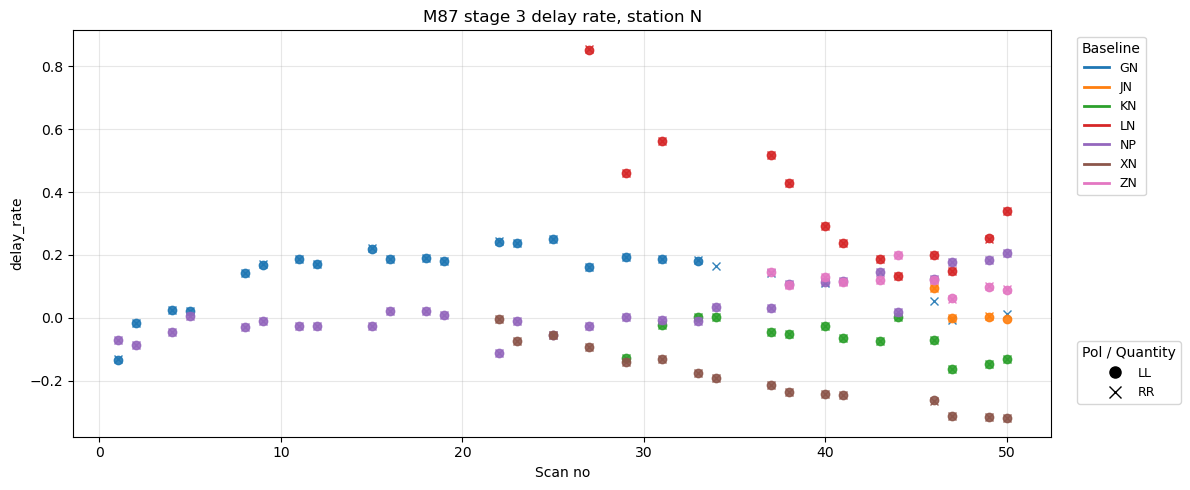

In [7]:
figs = plot_quantity_vs_scan_by_station(
    avg_scan_M87_stage3,
    stations=["N"],
    quantities="delay_rate",
    pols=["RR", "LL"],
    filters={"snr": (">=", 7)},
    title_prefix="M87 stage 3 delay rate"
)

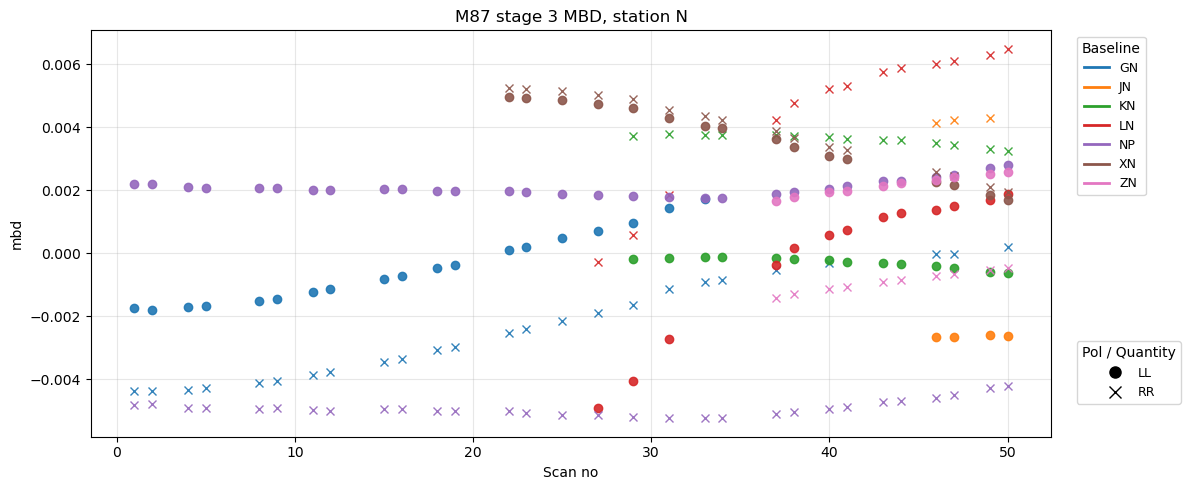

In [8]:
figs = plot_quantity_vs_scan_by_station(
    avg_scan_M87_stage3,
    stations=["N"],
    quantities="mbd",
    pols=["RR", "LL"],
    filters={"snr": (">=", 7)},
    title_prefix="M87 stage 3 MBD"
)

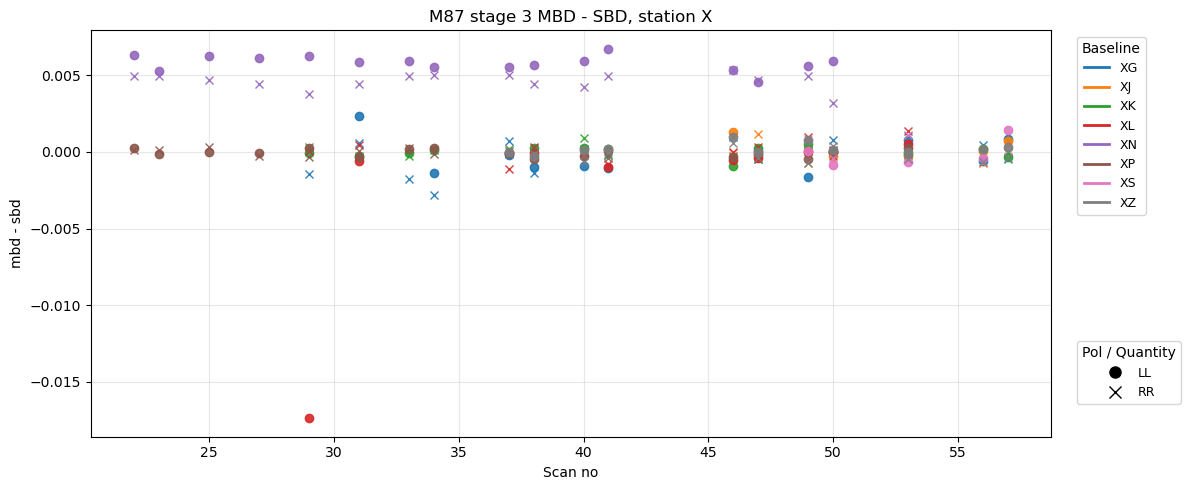

In [9]:
figs = plot_quantity_vs_scan_by_station(
    avg_scan_M87_stage3,
    stations=["X"],
    quantities="mbd - sbd",
    pols=["RR", "LL"],
    filters={"snr": (">=", 7)},
    title_prefix="M87 stage 3 MBD - SBD"
)

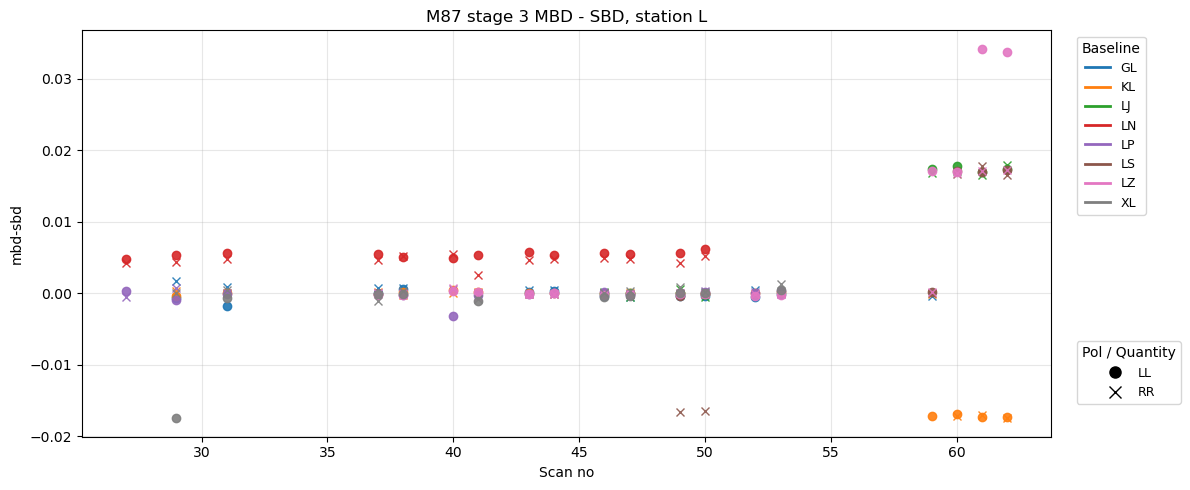

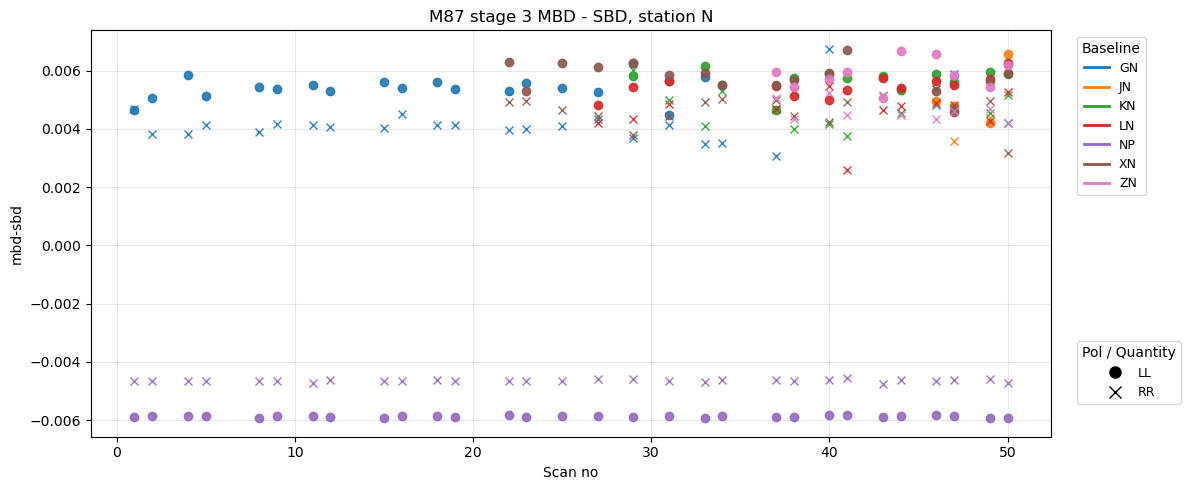

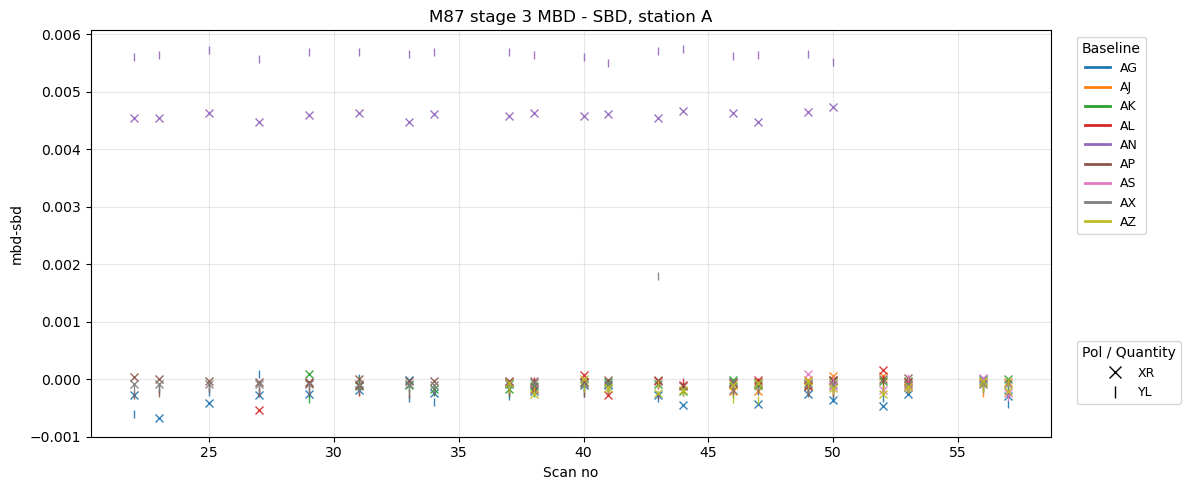

In [10]:
figs = plot_quantity_vs_scan_by_station(
    avg_scan_M87_stage3,
    stations=["L", "N", "A"],
    quantities=lambda d: d["mbdelay"] - d["sbdelay"],
    pols={
    "default": ["RR", "LL"],
    "A": ["XR", "YL"],
    },
    filters={"snr": (">=", 7)},
    ylabel="mbd-sbd",
    title_prefix="M87 stage 3 MBD - SBD"
)

Handle ALMA separately when calculating pol diff due to the mixed polarization.

In [11]:
mbd_diff = add_pol_difference(
    avg_scan_M87_stage5,
    quantity="mbdelay",
    pol1="RR",
    pol2="RL",
    new_col="mbdelay_RR_minus_RL",
)

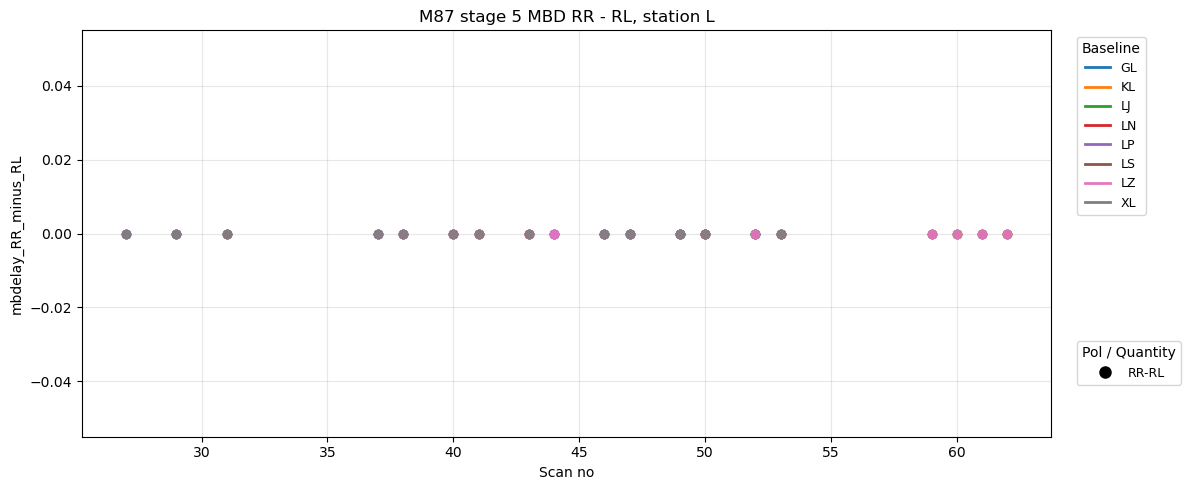

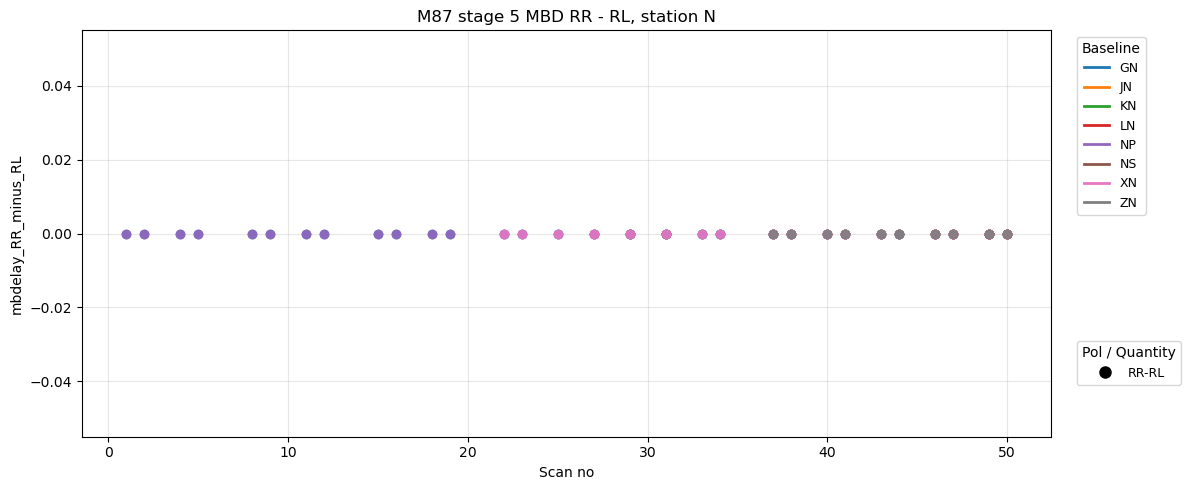

In [12]:
figs = plot_quantity_vs_scan_by_station(
    mbd_diff,
    stations=["L", "N"],
    quantities="mbdelay_RR_minus_RL",
    pols=["RR-RL"],
    title_prefix="M87 stage 5 MBD RR - RL"
)

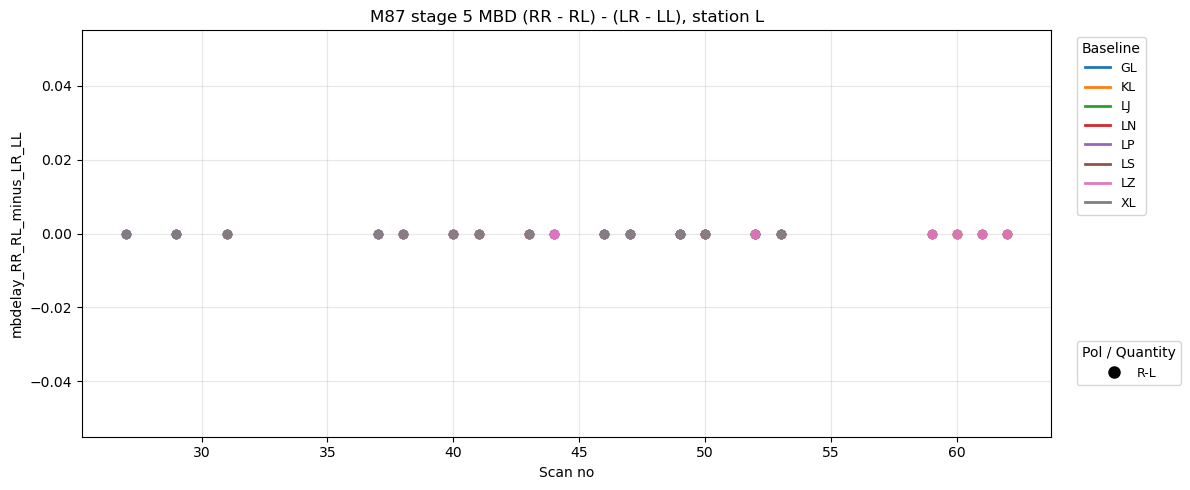

In [13]:
diff = add_rl_double_difference(
    avg_scan_M87_stage5,
    quantity="mbdelay",
    new_col="mbdelay_RR_RL_minus_LR_LL",
)

figs = plot_quantity_vs_scan_by_station(
    diff,
    stations=["L"],
    quantities="mbdelay_RR_RL_minus_LR_LL",
    pols=["R-L"],
    title_prefix="M87 stage 5 MBD (RR - RL) - (LR - LL)"
)

### 4. Return outliers based on SBD-MBD, delay rate, or R-L threshold

In [14]:
outliers = summarize_delay_outliers(
    avg_scan_M87_stage5,
    delay_col="mbdelay",
    sbd_col="sbdelay",
    rate_col="delay_rate",
    snr_col="snr",
    sbd_mbd_frac_threshold=0.2,
    rate_threshold=2.0,
    rl_dd_frac_threshold=0.2,
    snr_min=7,
    include_rl_double_difference=True,
)

In [15]:
outliers["sbd_mbd"].head(5)

,datetime,scan_no,source,baseline,polarization,snr,mbdelay,sbdelay,delay_rate,sbd_minus_mbd,abs_sbd_minus_mbd,sbd_mbd_frac,flag_sbd_mbd
5137,2022-03-27 11:39:00,61,M87,LZ,LL,57.876755,0.007920,-0.026213,-2.665904,-0.034133,0.034133,13.428658,True
5133,2022-03-27 11:39:00,61,M87,LZ,RR,57.872581,0.007920,-0.026213,-2.665904,-0.034133,0.034133,13.428658,True
5132,2022-03-27 11:39:00,61,M87,LZ,RL,8.468452,0.007920,-0.026213,-2.665904,-0.034133,0.034133,13.428658,True
5185,2022-03-27 12:07:00,62,M87,LZ,RR,21.875473,0.003348,-0.030785,-2.703119,-0.034133,0.034133,13.428657,True
5187,2022-03-27 12:07:00,62,M87,LZ,LL,22.482950,0.003348,-0.030785,-2.703119,-0.034133,0.034133,13.428657,True


In [16]:
outliers["delay_rate"].head(5)

,datetime,scan_no,source,baseline,polarization,snr,mbdelay,sbdelay,delay_rate,delay_rate_frac,flag_delay_rate
5247,2022-03-27 12:07:00,62,M87,KL,LL,23.412184,0.005463,0.022530,2.620834,6.302620,True
5201,2022-03-27 12:07:00,62,M87,KL,RR,23.500803,0.005463,0.022530,2.620834,6.302620,True
5187,2022-03-27 12:07:00,62,M87,LZ,LL,22.482950,0.003348,-0.030785,-2.703119,6.128658,True
5185,2022-03-27 12:07:00,62,M87,LZ,RR,21.875473,0.003348,-0.030785,-2.703119,6.128658,True
5183,2022-03-27 11:39:00,61,M87,KL,LL,64.948608,0.001105,0.018171,2.532301,6.095898,True


In [17]:
outliers["rl_double_difference"].head(5)

,scan_no,baseline,LL,LR,RL,RR,datetime,source,snr_LL,snr_LR,snr_RL,snr_RR,mbdelay_RR_minus_RL,mbdelay_LR_minus_LL,mbdelay_double_difference,abs_mbdelay_double_difference,mbdelay_double_difference_frac,flag_rl_double_difference,polarization


In [18]:
outliers["all_flags"].head(5)

,datetime,scan_no,source,baseline,polarization,snr,mbdelay,sbdelay,delay_rate,sbd_minus_mbd,sbd_mbd_frac,delay_rate_frac,flag_sbd_mbd,flag_delay_rate
752,2022-03-27 01:36:00,27,M87,LP,LL,10.714477,-0.003041,-0.003041,0.831367,0.000000,0.000000,2.124266,False,True
784,2022-03-27 01:36:00,27,M87,LN,RR,14.221951,-0.004897,-0.004897,0.856245,0.000000,0.000000,2.182355,False,True
794,2022-03-27 01:36:00,27,M87,LP,RR,11.375370,-0.003041,-0.003041,0.831367,0.000000,0.000000,2.124266,False,True
795,2022-03-27 01:36:00,27,M87,LN,LL,13.378980,-0.004897,-0.004897,0.856245,0.000000,0.000000,2.182355,False,True
888,2022-03-27 01:56:00,29,M87,XL,RR,11.340720,-0.008412,0.008655,-0.601914,0.017067,6.714309,1.222404,True,False
